# Task del Machine Learning: classificazione e regressione

## L'analisi predittiva

In questo corso ci concentreremo soprattutto sull'**analisi predittiva**. A partire da esempi per i quali conosciamo già la risposta, cercheremo di costruire una funzione capace di fornire una previsione su nuove osservazioni.

In forma schematica:

$$
\text{dati di esempio}
\longrightarrow
\text{apprendimento di un modello}
\longrightarrow
\text{previsione su nuovi dati}.
$$

Due problemi predittivi fondamentali sono:

- la **classificazione**, quando la risposta è una categoria;
- la **regressione**, quando la risposta è una quantità numerica.

Cominciamo dall'idea di classificazione.

### 1.4 Un primo esempio

Supponiamo di conoscere, per un insieme di studenti:

- il numero di ore dedicate allo studio;
- la percentuale di lezioni frequentate;
- il voto ottenuto all'esame.

A partire da questi dati possiamo formulare diverse domande:

- Qual è il voto medio?
- Quanto sono variabili i risultati?
- Esiste una relazione tra ore di studio e voto?
- Sono presenti studenti con un comportamento anomalo?
- Possiamo dividere gli studenti in gruppi con caratteristiche simili?

Prima di scegliere un algoritmo dobbiamo quindi chiarire **quale domanda vogliamo porre ai dati**.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

studenti = pd.DataFrame({
    'Studente': ['Anna', 'Bruno', 'Carla', 'Davide', 'Elena', 'Fabio', 'Giulia', 'Luca'],
    'Ore_studio': [12, 25, 18, 8, 22, 15, 28, 10],
    'Frequenza': [70, 90, 80, 60, 85, 75, 95, 65],
    'Voto': [21, 28, 25, 19, 27, 23, 30, 20]
})

studenti

,Studente,Ore_studio,Frequenza,Voto
0,Anna,12,70,21
1,Bruno,25,90,28
2,Carla,18,80,25
3,Davide,8,60,19
4,Elena,22,85,27
5,Fabio,15,75,23
6,Giulia,28,95,30
7,Luca,10,65,20


Nella tabella precedente:

- ogni **riga** corrisponde a un'osservazione, cioè a uno studente;
- ogni **colonna** corrisponde a una variabile;
- le variabili numeriche possono essere utilizzate nei calcoli;
- il nome dello studente è invece una variabile identificativa.

**Per riflettere**

Consideriamo un'applicazione che deve analizzare automaticamente immagini mediche.

1. Che cosa rappresentano le osservazioni?
2. Quali potrebbero essere le variabili o feature?
3. Da quali sorgenti potrebbe provenire il rumore?
4. Quali conseguenze potrebbe avere un errore dell'algoritmo?
5. L'accuratezza numerica è l'unico criterio con cui valutarlo?

Queste domande mostrano perché l'analisi dei dati richiede sia strumenti matematici e computazionali sia una conoscenza del contesto applicativo.

## 2. Dall'analisi descrittiva all'analisi predittiva

Descrivere i dati disponibili è soltanto una parte dell'analisi dei dati. Molto spesso vogliamo utilizzare ciò che abbiamo osservato per formulare una **previsione su nuovi dati**.

Esempi di domande predittive sono:

- un messaggio di posta elettronica è *spam* oppure *non spam*?
- un'immagine contiene un gatto, un cane oppure un altro animale?
- una transazione bancaria è regolare oppure fraudolenta?
- un'immagine medica mostra un tessuto sano oppure patologico?

Quando il risultato da prevedere appartiene a un insieme finito di categorie, abbiamo un problema di **classificazione**.

**Due problemi predittivi fondamentali**

Nell'apprendimento supervisionato distinguiamo soprattutto:

- **classificazione**, se $y$ è una categoria;
- **regressione**, se $y$ è una quantità numerica.

```{figure} immagini_sorgente/classificazione_regressione.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/classificazione_regressione.png" width="700">
</p> -->

In entrambi i casi il modello deve individuare una relazione tra gli input e gli output osservati, per poi applicarla a nuovi dati. Cambiano il tipo di risposta e le misure utilizzate per valutare l'errore.

### 2.1 Che cos'è un classificatore?

Ogni oggetto viene descritto mediante un insieme di caratteristiche numeriche, dette **feature**. Queste caratteristiche formano un vettore

$$
\mathbf{x}=(x_1,x_2,\ldots,x_n)\in\mathbb{R}^n.
$$

Un classificatore riceve il vettore $\mathbf{x}$ e gli assegna una classe:

$$
f:\mathbb{R}^n\longrightarrow\{C_1,C_2,\ldots,C_K\}.
$$

```{figure} immagini_sorgente/schema_classificazione.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/schema_classificazione.png" width="700">
</p> -->

### 2.3 Apprendimento supervisionato

Come possiamo costruire la funzione $f$? Disponiamo di un insieme di esempi per i quali la classe corretta è già nota:

$$
\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^m,
$$

dove $\mathbf{x}_i$ contiene le caratteristiche dell'osservazione $i$ e $y_i$ è la sua **etichetta**, o *label*.

Si parla di **apprendimento supervisionato** perché durante l'apprendimento il metodo conosce sia i dati in ingresso sia le risposte corrette.

*Un piccolo dataset a due classi*

Consideriamo dodici oggetti. Ogni oggetto è descritto da due caratteristiche, $x_1$ e $x_2$, ed è associato alla **classe A** oppure alla **classe B**. Poiché ci sono soltanto due possibili etichette, questo è un problema di **classificazione binaria**.

```{figure} immagini_sorgente/dati_due_classi.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/dati_due_classi.png" width="700">
</p> -->

Ogni punto rappresenta un'osservazione. La sua posizione dipende dalle caratteristiche, mentre il colore e la forma indicano la classe nota.

Se le possibili etichette fossero più di due, per esempio gatto, cane e cavallo, parleremmo invece di **classificazione multiclasse**.



Il classificatore suddivide lo spazio delle caratteristiche in regioni associate alle diverse classi. Il confine tra queste regioni prende il nome di **frontiera di decisione**.

```{figure} immagini_sorgente/frontiera_classificazione.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/frontiera_classificazione.png" width="700">
</p> -->

Una volta costruita la frontiera, una nuova osservazione viene classificata in base alla regione in cui si trova.

> La frontiera mostrata nella figura serve soltanto a illustrare il concetto: nei problemi reali deve essere appresa dai dati.

### 2.4 Una prima idea di classificazione

Consideriamo un insieme di fiori descritti mediante due caratteristiche:

- la lunghezza del petalo;
- la larghezza del petalo.

Per ogni fiore conosciamo inoltre la specie, che può essere **Setosa** oppure **Versicolor**. La specie è la **classe** o **etichetta** (*label*) che vogliamo prevedere.

Il nostro obiettivo è usare gli esempi disponibili per assegnare una classe a un nuovo fiore.

In [2]:
# Un piccolo dataset ispirato al dataset Iris
fiori = pd.DataFrame({
    'Lunghezza_petalo': [1.4, 1.3, 1.5, 1.7, 1.4, 1.6,
                         4.7, 4.5, 4.9, 4.0, 4.6, 4.4],
    'Larghezza_petalo': [0.2, 0.2, 0.2, 0.4, 0.3, 0.2,
                         1.4, 1.5, 1.5, 1.3, 1.5, 1.3],
    'Specie': ['Setosa'] * 6 + ['Versicolor'] * 6
})

fiori

,Lunghezza_petalo,Larghezza_petalo,Specie
0,1.4,0.2,Setosa
1,1.3,0.2,Setosa
2,1.5,0.2,Setosa
3,1.7,0.4,Setosa
4,1.4,0.3,Setosa
5,1.6,0.2,Setosa
6,4.7,1.4,Versicolor
7,4.5,1.5,Versicolor
8,4.9,1.5,Versicolor
9,4.0,1.3,Versicolor


In un problema di apprendimento supervisionato ogni osservazione è formata da:

$$
(\mathbf{x}_i,y_i), \qquad i=1,\ldots,m,
$$

dove

$$
\mathbf{x}_i=
\begin{bmatrix}
\text{lunghezza del petalo}\\
\text{larghezza del petalo}
\end{bmatrix}
\in\mathbb{R}^2
$$

è il vettore delle caratteristiche e $y_i$ è l'etichetta associata al fiore.

In questo esempio cerchiamo quindi una funzione

$$
f:\mathbb{R}^2\longrightarrow\{\text{Setosa},\text{Versicolor}\}.
$$

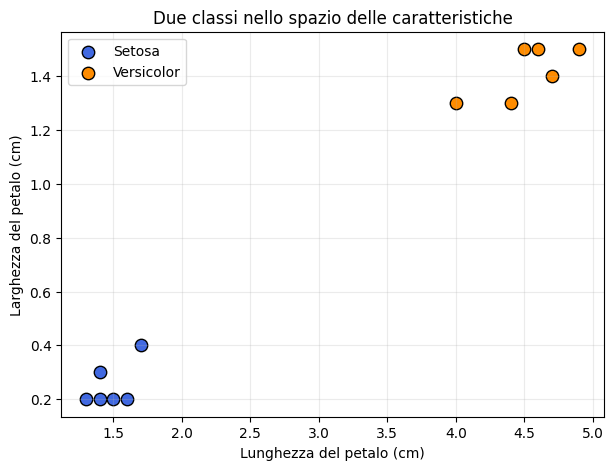

In [3]:
colori = {'Setosa': 'royalblue', 'Versicolor': 'darkorange'}

plt.figure(figsize=(7, 5))
for specie, gruppo in fiori.groupby('Specie'):
    plt.scatter(gruppo['Lunghezza_petalo'], gruppo['Larghezza_petalo'],
                s=80, color=colori[specie], edgecolor='black', label=specie)

plt.xlabel('Lunghezza del petalo (cm)')
plt.ylabel('Larghezza del petalo (cm)')
plt.title('Due classi nello spazio delle caratteristiche')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Nel grafico ogni punto rappresenta un fiore. La posizione dipende dalle sue caratteristiche, mentre il colore indica la classe nota.

Osserviamo che le due specie occupano regioni differenti dello spazio. Un metodo di classificazione cerca di ricavare dai dati una **regola di decisione** che separi tali regioni.

Per un nuovo fiore con caratteristiche

$$
\mathbf{x}_{\mathrm{new}}=
\begin{bmatrix}
4.2\\1.4
\end{bmatrix},
$$

quale classe assegneremmo osservando il grafico?

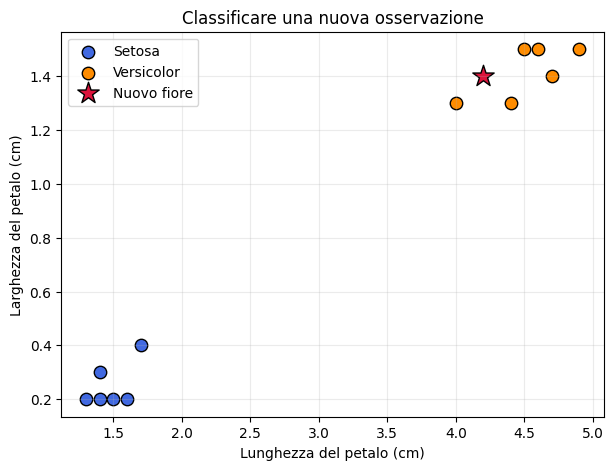

In [4]:
nuovo_fiore = np.array([4.2, 1.4])

plt.figure(figsize=(7, 5))
for specie, gruppo in fiori.groupby('Specie'):
    plt.scatter(gruppo['Lunghezza_petalo'], gruppo['Larghezza_petalo'],
                s=80, color=colori[specie], edgecolor='black', label=specie)

plt.scatter(nuovo_fiore[0], nuovo_fiore[1], marker='*', s=260,
            color='crimson', edgecolor='black', label='Nuovo fiore')
plt.xlabel('Lunghezza del petalo (cm)')
plt.ylabel('Larghezza del petalo (cm)')
plt.title('Classificare una nuova osservazione')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

### 2.5 Apprendimento e valutazione

I dati usati per costruire la regola di classificazione costituiscono il **training set**. Valutare il modello sugli stessi esempi, però, non ci dice quanto sarà efficace su dati mai osservati.

Per questo si separano normalmente i dati in:

- **training set**, utilizzato per apprendere il modello;
- **test set**, utilizzato per valutarne la capacità predittiva su nuovi dati.

Una prima misura di prestazione è l'**accuratezza**:

$$
\operatorname{accuracy}=
\frac{\text{numero di classificazioni corrette}}
{\text{numero totale di esempi nel test set}}.
$$

Nei problemi reali l'accuratezza non è sempre sufficiente: il significato e il costo dei diversi tipi di errore possono essere molto differenti.

### Domande per la discussione

1. Quali informazioni costituiscono l'input del classificatore?
2. Qual è l'output?
3. Il problema è binario o multiclasse?
4. Che cosa accadrebbe se le due nuvole di punti si sovrapponessero?
5. È possibile ottenere un'accuratezza perfetta sul training set ma commettere errori sui nuovi dati?
6. In una diagnosi medica, tutti gli errori di classificazione avrebbero lo stesso costo?

### 2.6 La scelta del modello

Gli stessi dati possono essere rappresentati utilizzando *modelli* differenti. Per esempio, possiamo scegliere come modello una retta oppure una parabola.

```{figure} immagini_sorgente/modelli_lineare_quadratico.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/modelli_lineare_quadratico.png" width="700">
</p> -->

Nel primo caso il modello ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x,
$$

mentre nel secondo caso ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

La famiglia scelta non deve necessariamente essere quella dei polinomi. Per esempio, possiamo considerare una combinazione lineare di una funzione esponenziale e di una costante:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1 e^{\alpha x}.
$$

```{figure} immagini_sorgente/modello_esponenziale.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/modello_esponenziale.png" width="700">
</p> -->

La scelta della famiglia di funzioni dipende dal fenomeno che vogliamo descrivere e dalle informazioni disponibili sui dati.

### 2.6 I modelli: famiglie parametriche di funzioni

Scelta una famiglia di funzioni $f(x;\boldsymbol{\theta})$, occorre determinare i parametri

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_{k-1})^T\in\mathbb{R}^{k}
$$

che identificano la particolare funzione della famiglia che meglio rappresenta i dati.

Per esempio, scegliendo come famiglia le rette del piano, dobbiamo determinare

$$
\boldsymbol{\theta}=(\theta_0,\theta_1)^T,
$$

dove $\theta_0$ è l'intercetta e $\theta_1$ è il coefficiente angolare. Il problema consiste quindi nel trovare la retta che meglio approssima i punti dati.

**Come confrontare due modelli?**

Per stabilire se una funzione rappresenta i dati meglio di un'altra dobbiamo introdurre una misura di vicinanza tra i valori previsti e quelli osservati.

Questo viene fatto definendo una **funzione di costo**, detta anche **funzione di perdita** o *loss function*. Indicata con $h$ la perdita relativa a una singola osservazione, definiamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr).
$$

La funzione di costo dipende dai parametri perché, al variare di $\boldsymbol{\theta}$, cambiano le previsioni del modello.

*Il calcolo dei parametri come problema di minimo*

I parametri ottimali sono quelli che rendono minima la funzione di costo:

$$
\boldsymbol{\theta}^{*}
=\operatorname*{argmin}_{\boldsymbol{\theta}\in\mathbb{R}^{k}}
\mathcal{L}(\boldsymbol{\theta}).
$$

La funzione $f(x;\boldsymbol{\theta}^{*})$, i cui parametri sono stati stimati minimizzando la funzione di perdita, prende il nome di **funzione di regressione**.

> Il problema di costruire un modello predittivo viene così trasformato in un problema di ottimizzazione.

### 2.7 L'approccio del Machine Learning

Nella programmazione tradizionale il programmatore specifica esplicitamente le regole che trasformano i dati in risultati. Questo approccio diventa difficile quando le regole sono troppo numerose, complesse o impossibili da descrivere in modo preciso.

Nel **Machine Learning** non scriviamo direttamente tutte le regole: forniamo esempi a un algoritmo, che cerca nei dati le regolarità utili per costruire un modello predittivo.

```{figure} immagini_sorgente/tradizionale_vs_ml.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/tradizionale_vs_ml.png" width="700">
</p>

> Un sistema di Machine Learning apprende dai dati una regola che non è stata programmata esplicitamente.

*Imparare dagli esempi*

L'apprendimento automatico può essere paragonato allo studio di uno studente:

- durante il **training**, lo studente studia esempi ed esercizi già svolti;
- durante il **test**, affronta domande nuove;
- la **valutazione** misura quanto ciò che ha appreso sia trasferibile a situazioni mai viste.

```{figure} immagini_sorgente/studying_training_evaluation.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/studying_training_evaluation.png" width="700">
</p> -->

Se le domande dell'esame fossero identiche agli esercizi studiati, non potremmo capire se lo studente ha davvero imparato. Analogamente, un modello deve essere valutato su dati non utilizzati durante il training.



Nell'**apprendimento supervisionato** disponiamo di un insieme di esempi

$$
\mathcal{D}_{\mathrm{train}}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{m},
$$

dove $\mathbf{x}_i$ contiene le caratteristiche dell'osservazione e $y_i$ è la risposta corretta.

L'**algoritmo di apprendimento** usa il training set per determinare un modello $f_{\boldsymbol{\theta}}$. Una volta costruito, il modello riceve un nuovo input e produce una previsione:

$$
\mathbf{x}_{\mathrm{new}}
\longrightarrow
f_{\boldsymbol{\theta}}(\mathbf{x}_{\mathrm{new}})
=\widehat{y}_{\mathrm{new}}.
$$

È importante distinguere:

- l'**algoritmo**, cioè la procedura che apprende;
- il **modello**, cioè la funzione ottenuta al termine dell'apprendimento;
- la **predizione**, cioè l'output del modello per un nuovo dato.

### 2.8 L'obiettivo: generalizzare

Lo scopo non è riprodurre perfettamente gli esempi già osservati, ma ottenere buone previsioni su dati nuovi. Questa capacità prende il nome di **generalizzazione**.

```{figure} immagini_sorgente/training_test.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/training_test.png" width="700">
</p> -->

- Il **training set** serve ad apprendere i parametri del modello.
- Il **test set** deve essere usato soltanto per la valutazione finale.

Un modello troppo semplice può non cogliere la struttura dei dati (**underfitting**); un modello che si adatta anche al rumore del training set può invece non funzionare su nuovi dati (**overfitting**).

> La qualità di un modello si misura sulla sua capacità di prevedere, non sulla sua capacità di ricordare.

### 2.6 La scelta del modello

Gli stessi dati possono essere rappresentati utilizzando *modelli* differenti. Per esempio, possiamo scegliere come modello una retta oppure una parabola.

![](immagini_sorgente/modelli_lineare_quadratico.png)

<!-- ```{figure} immagini_sorgente/modelli_lineare_quadratico.png
---
width: 100%
align: center
---
```
<!-- <p align="center">
  <img src="immagini_sorgente/modelli_lineare_quadratico.png" width="700">
</p> --> -->

Nel primo caso il modello ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x,
$$

mentre nel secondo caso ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

### 1.1 I modelli: famiglie parametriche di funzioni

Scelta una famiglia di funzioni $f(x;\boldsymbol{\theta})$, occorre determinare i parametri

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_{k-1})^T\in\mathbb{R}^{k}
$$

che identificano la particolare funzione della famiglia che meglio rappresenta i dati.

Per esempio, scegliendo come famiglia le rette del piano, dobbiamo determinare

$$
\boldsymbol{\theta}=(\theta_0,\theta_1)^T,
$$

dove $\theta_0$ è l'intercetta e $\theta_1$ è il coefficiente angolare. Il problema consiste quindi nel trovare la retta che meglio approssima i punti dati.

**Come confrontare due modelli?**

Per stabilire se una funzione rappresenta i dati meglio di un'altra dobbiamo introdurre una misura di vicinanza tra i valori previsti e quelli osservati.

Questo viene fatto definendo una **funzione di costo**, detta anche **funzione di perdita** o *loss function*. Indicata con $h$ la perdita relativa a una singola osservazione, definiamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr).
$$

La funzione di costo dipende dai parametri perché, al variare di $\boldsymbol{\theta}$, cambiano le previsioni del modello.

*Il calcolo dei parametri come problema di minimo*

I parametri ottimali sono quelli che rendono minima la funzione di costo:

$$
\boldsymbol{\theta}^{*}
=\operatorname*{argmin}_{\boldsymbol{\theta}\in\mathbb{R}^{k}}
\mathcal{L}(\boldsymbol{\theta}).
$$

La funzione $f(x;\boldsymbol{\theta}^{*})$, i cui parametri sono stati stimati minimizzando la funzione di perdita, prende il nome di **funzione di regressione**.

> Il problema di costruire un modello predittivo viene così trasformato in un problema di ottimizzazione.

### 2.7 L'approccio del Machine Learning

Nella programmazione tradizionale il programmatore specifica esplicitamente le regole che trasformano i dati in risultati. Questo approccio diventa difficile quando le regole sono troppo numerose, complesse o impossibili da descrivere in modo preciso.

Nel **Machine Learning** non scriviamo direttamente tutte le regole: forniamo esempi a un algoritmo, che cerca nei dati le regolarità utili per costruire un modello predittivo.

![](immagini_sorgente/tradizionale_vs_ml.png)

<!-- ```{figure} immagini_sorgente/tradizionale_vs_ml.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/tradizionale_vs_ml.png" width="700">
</p> -->

> Un sistema di Machine Learning apprende dai dati una regola che non è stata programmata esplicitamente.

*Imparare dagli esempi*

L'apprendimento automatico può essere paragonato allo studio di uno studente:

- durante il **training**, lo studente studia esempi ed esercizi già svolti;
- durante il **test**, affronta domande nuove;
- la **valutazione** misura quanto ciò che ha appreso sia trasferibile a situazioni mai viste.

![](immagini_sorgente/studying_training_evaluation.png)

<!-- ```{figure} immagini_sorgente/studying_training_evaluation.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/studying_training_evaluation.png" width="700">
</p> -->

Se le domande dell'esame fossero identiche agli esercizi studiati, non potremmo capire se lo studente ha davvero imparato. Analogamente, un modello deve essere valutato su dati non utilizzati durante il training.



Nell'**apprendimento supervisionato** disponiamo di un insieme di esempi

$$
\mathcal{D}_{\mathrm{train}}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{m},
$$

dove $\mathbf{x}_i$ contiene le caratteristiche dell'osservazione e $y_i$ è la risposta corretta.

L'**algoritmo di apprendimento** usa il training set per determinare un modello $f_{\boldsymbol{\theta}}$. Una volta costruito, il modello riceve un nuovo input e produce una previsione:

$$
\mathbf{x}_{\mathrm{new}}
\longrightarrow
f_{\boldsymbol{\theta}}(\mathbf{x}_{\mathrm{new}})
=\widehat{y}_{\mathrm{new}}.
$$

È importante distinguere:

- l'**algoritmo**, cioè la procedura che apprende;
- il **modello**, cioè la funzione ottenuta al termine dell'apprendimento;
- la **predizione**, cioè l'output del modello per un nuovo dato.

### 2.8 L'obiettivo: generalizzare

Lo scopo non è riprodurre perfettamente gli esempi già osservati, ma ottenere buone previsioni su dati nuovi. Questa capacità prende il nome di **generalizzazione**.

![](immagini_sorgente/training_validation_test.png)

<!-- ```{figure} immagini_sorgente/training_validation_test.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/training_validation_test.png" width="700">
</p> -->

- Il **training set** serve ad apprendere i parametri del modello.
- Il **validation set** serve a confrontare scelte e configurazioni.
- Il **test set** deve essere usato soltanto per la valutazione finale.

Un modello troppo semplice può non cogliere la struttura dei dati (**underfitting**); un modello che si adatta anche al rumore del training set può invece non funzionare su nuovi dati (**overfitting**).

> La qualità di un modello si misura sulla sua capacità di prevedere, non sulla sua capacità di ricordare.

###  Il problema dei minimi quadrati nell'approssimazione dei dati. 

Supponiamo di avere un insieme di dati

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{n},
$$

dove $x_i$ è il dato in ingresso e $y_i$ è il valore osservato.

L'obiettivo è determinare una funzione che rappresenti nel modo migliore possibile la relazione tra $x$ e $y$ e che possa essere utilizzata per prevedere il valore corrispondente a un nuovo dato in ingresso.

**La scelta del modello**

Gli stessi dati possono essere rappresentati utilizzando famiglie di funzioni differenti. Per esempio, possiamo scegliere come modello una retta oppure una parabola.

![](immagini_sorgente/modelli_lineare_quadratico.png)

<!-- ```{figure} immagini_sorgente/modelli_lineare_quadratico.png
---
width: 100%
align: center
---
```
<p align="center">
  <img src="immagini_sorgente/modelli_lineare_quadratico.png" width="700">
</p> -->

Nel primo caso il modello ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x,
$$

mentre nel secondo caso ha la forma

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

## 7.6 Famiglie parametriche di funzioni

Scelta una famiglia di funzioni $f(x;\boldsymbol{\theta})$, occorre determinare i parametri

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_{k-1})^T\in\mathbb{R}^{k}
$$

che identificano la particolare funzione della famiglia che meglio rappresenta i dati.

Per esempio, scegliendo come famiglia le rette del piano, dobbiamo determinare

$$
\boldsymbol{\theta}=(\theta_0,\theta_1)^T,
$$

dove $\theta_0$ è l'intercetta e $\theta_1$ è il coefficiente angolare. Il problema consiste quindi nel trovare la retta che meglio approssima i punti dati.

**Come confrontare due modelli?**

Per stabilire se una funzione rappresenta i dati meglio di un'altra dobbiamo introdurre una misura di vicinanza tra i valori previsti e quelli osservati.

Questo viene fatto definendo una **funzione di costo**, detta anche **funzione di perdita** o *loss function*. Indicata con $h$ la perdita relativa a una singola osservazione, definiamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr).
$$

La funzione di costo dipende dai parametri perché, al variare di $\boldsymbol{\theta}$, cambiano le previsioni del modello.

### 7.7 Il calcolo dei parametri come problema di minimo

I parametri ottimali sono quelli che rendono minima la funzione di costo:

$$
\boldsymbol{\theta}^{*}
=\operatorname*{argmin}_{\boldsymbol{\theta}\in\mathbb{R}^{k}}
\mathcal{L}(\boldsymbol{\theta}).
$$

La funzione $f(x;\boldsymbol{\theta}^{*})$, i cui parametri sono stati stimati minimizzando la funzione di perdita, prende il nome di **funzione di regressione**.

> Il problema di costruire un modello predittivo viene così trasformato in un problema di ottimizzazione.

### 7.8 Regressione e perdita quadratica

Nella regressione si utilizza frequentemente la perdita quadratica

$$
h\bigl(f(x_i;\boldsymbol{\theta}),y_i\bigr)
=\bigl(f(x_i;\boldsymbol{\theta})-y_i\bigr)^2.
$$

La funzione di costo diventa quindi

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}\bigl(f(x_i;\boldsymbol{\theta})-y_i\bigr)^2.
$$

Ogni termine misura il quadrato del residuo relativo all'osservazione $i$. Gli errori di segno opposto non si cancellano e gli errori grandi vengono penalizzati maggiormente.



Nel caso della **regressione lineare**, il polinomio è una retta:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x.
$$

Nel caso della **regressione quadratica**, il polinomio è una parabola:

$$
f(x;\boldsymbol{\theta})=\theta_0+\theta_1x+\theta_2x^2.
$$

In generale, un polinomio di grado $k$ dipende da $k+1$ parametri:

$$
f(x;\boldsymbol{\theta})
=\theta_0+\theta_1x+\theta_2x^2+\cdots+\theta_kx^k.
$$

*La funzione di perdita per la regressione polinomiale*

Sostituendo il modello polinomiale nella perdita quadratica otteniamo

$$
\mathcal{L}(\boldsymbol{\theta})
=\sum_{i=1}^{n}
\left(\theta_0+\theta_1x_i+\theta_2x_i^2+\cdots+\theta_kx_i^k-y_i\right)^2.
$$

Introduciamo i vettori

$$
\boldsymbol{\theta}=(\theta_0,\theta_1,\ldots,\theta_k)^T,
\qquad
\mathbf{y}=(y_1,y_2,\ldots,y_n)^T,
$$

e la matrice

$$
\Phi=
\begin{pmatrix}
x_1^0 & x_1^1 & \cdots & x_1^k\\
x_2^0 & x_2^1 & \cdots & x_2^k\\
\vdots & \vdots & \ddots & \vdots\\
x_n^0 & x_n^1 & \cdots & x_n^k
\end{pmatrix}
\in\mathbb{R}^{n\times(k+1)}.
$$

La matrice $\Phi$ viene spesso chiamata **matrice del modello** o **design matrix**.

*Formulazione matriciale*

Il vettore delle previsioni del modello sui punti osservati è

$$
\widehat{\mathbf{y}}=\Phi\boldsymbol{\theta}.
$$

Il vettore dei residui è quindi

$$
\mathbf{r}=\Phi\boldsymbol{\theta}-\mathbf{y},
$$

e la funzione di perdita può essere scritta in forma compatta come

$$
\mathcal{L}(\boldsymbol{\theta})
=\|\Phi\boldsymbol{\theta}-\mathbf{y}\|_2^2.
$$



La determinazione dei coefficienti del polinomio conduce quindi al problema dei minimi quadrati lineari.

$$
\min_{\boldsymbol{\theta}\in\mathbb{R}^{k+1}}
\|\Phi\boldsymbol{\theta}-\mathbf{y}\|_2^2,
$$



*Il problema*

Supponiamo di osservare coppie $(t_i,y_i)$ e di voler descrivere la relazione con una retta

$$
y_i\approx\beta_0+\beta_1t_i.
$$

Per tutte le osservazioni il modello diventa

$$
\underbrace{\begin{bmatrix}
1&t_1\\1&t_2\\\vdots&\vdots\\1&t_m
\end{bmatrix}}_{A}
\underbrace{\begin{bmatrix}\theta_0\\\theta_1\end{bmatrix}}_{x}
\approx
\underbrace{\begin{bmatrix}y_1\\y_2\\\vdots\\y_m\end{bmatrix}}_{b}.
$$

La prima colonna di uno permette di rappresentare l'intercetta $\beta_0$. Stimare la retta significa risolvere un problema lineare ai minimi quadrati.

*Esempio: spesa pubblicitaria e vendite*

Consideriamo un piccolo dataset in cui $t$ rappresenta la spesa pubblicitaria e $y$ le vendite. Cerchiamo la retta che descrive meglio la relazione media tra le due variabili.

I segmenti verticali nel grafico rappresenteranno i residui $y_i-\widehat y_i$.

```{figure} immagini_sorgente/fig_regressione_residui.png
---
width: 100%
align: center
---
```

<p align="center">
  <img src="immagini_sorgente/fig_regressione_residui.png" width="700">
</p>

In [ ]:
pubblicita = np.array([2, 4, 5, 7, 8, 10, 12, 14, 15, 18.])
vendite = np.array([15, 18, 21, 24, 27, 30, 32, 36, 35, 42.])
A_reg = np.column_stack((np.ones(len(pubblicita)), pubblicita))
theta, _, _, _ = np.linalg.lstsq(A_reg, vendite, rcond=None)
vendite_stimate = A_reg @ beta

griglia = np.linspace(pubblicita.min(), pubblicita.max(), 200)
retta = theta[0] + bethetata[1]*griglia

plt.figure(figsize=(8, 5))
plt.scatter(pubblicita, vendite, s=55, label='dati osservati')
plt.plot(griglia, retta, color='tab:red', lw=2.2, label='retta LSQ')
for x_i, y_i, yh_i in zip(pubblicita, vendite, vendite_stimate):
    plt.plot([x_i, x_i], [yh_i, y_i], color='0.55', lw=1)
plt.xlabel('Spesa pubblicitaria')
plt.ylabel('Vendite')
plt.title('Regressione lineare mediante minimi quadrati')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f'Intercetta beta_0 = {beta[0]:.3f}')
print(f'Pendenza   beta_1 = {beta[1]:.3f}')

*Interpretazione dei coefficienti*

Nel modello

$$
\widehat y=\theta_0+\theta_1t,
$$

l'intercetta $\theta_0$ è il valore previsto quando $t=0$, mentre la pendenza $\theta_1$ è la variazione media prevista di $y$ associata a un aumento unitario di $t$.

Questa interpretazione deve essere fatta nel dominio osservato: estrapolare molto oltre i valori presenti nei dati può essere inaffidabile. Inoltre una relazione statistica non implica automaticamente un rapporto causale.

*Misure dell'errore*

Indicando con $e_i=y_i-\widehat y_i$ i residui, sono comuni le seguenti quantità:

$$
\mathrm{SSE}=\sum_{i=1}^{m}e_i^2,
$$

$$
\mathrm{MSE}=\frac1m\sum_{i=1}^{m}e_i^2,
\qquad
\mathrm{RMSE}=\sqrt{\mathrm{MSE}},
$$

$$
R^2=1-\frac{\sum_i(y_i-\widehat y_i)^2}
{\sum_i(y_i-\overline y)^2}.
$$

L'RMSE ha la stessa unità di misura della variabile risposta. $R^2$ misura la frazione di variabilità spiegata rispetto al semplice uso della media, ma non dimostra che il modello sia corretto.

In [ ]:
errori = vendite-vendite_stimate
SSE = np.sum(errori**2)
MSE = np.mean(errori**2)
RMSE = np.sqrt(MSE)
R2 = 1-SSE/np.sum((vendite-vendite.mean())**2)

print(f'SSE  = {SSE:.4f}')
print(f'MSE  = {MSE:.4f}')
print(f'RMSE = {RMSE:.4f}')
print(f'R^2  = {R2:.4f}')

## Modelli polinomiali

Anche un modello come

$$
y\approx\theta_0+\theta_1t+\theta_2t^2
$$

è un problema lineare ai minimi quadrati, perché è lineare rispetto ai parametri $\theta_0,\theta_1,\theta_2$. Basta costruire la matrice

$$
A=\begin{bmatrix}
1&t_1&t_1^2\\
\vdots&\vdots&\vdots\\
1&t_m&t_m^2
\end{bmatrix}.
$$

Un grado elevato può però produrre mal condizionamento e adattamento eccessivo ai dati.

 **Aspetti pratici nell'analisi dei dati**

*Intercetta*
Per includere un termine costante bisogna aggiungere ad $A$ una colonna di uno. Ometterla forza il modello a passare per l'origine.

*Scala delle variabili*
Cambiare unità di misura non modifica le previsioni di un modello LSQ non regolarizzato, ma può peggiorare il condizionamento e rendere difficili i confronti tra coefficienti. Centrare e scalare le variabili può aiutare.

*Valori anomali*
Poiché gli errori vengono elevati al quadrato, gli outlier (dati lontani dal centro della distribuzione) possono spostare sensibilmente la soluzione. È importante ispezionare dati e residui.

### 7.9 Minimi quadrati pesati

Se alcune osservazioni sono più affidabili di altre, possiamo assegnare pesi $w_i>0$ e risolvere

$$
\min_x\sum_{i=1}^{m}w_i(b_i-a_i^Tx)^2.
$$

In forma matriciale, con $W=\operatorname{diag}(w_1,\ldots,w_m)$,

$$
\min_x\|W^{1/2}(b-Ax)\|_2^2.
$$

Si tratta ancora di un problema lineare ai minimi quadrati, applicato alla matrice $W^{1/2}A$ e al vettore $W^{1/2}b$.

### 7.10 Regolarizzazione di Tikhonov o Ridge

Quando il problema è mal condizionato o ha molte variabili, si può penalizzare la grandezza della soluzione:

$$
\min_x\bigl(\|b-Ax\|_2^2+\lambda\|x\|_2^2\bigr),
\qquad \lambda>0.
$$

Le corrispondenti equazioni sono

$$
(A^TA+\lambda I)x=A^Tb.
$$

Il parametro $\lambda$ controlla il compromesso tra aderenza ai dati e stabilità: aumentando $\lambda$ i coefficienti vengono ridotti, introducendo distorsione ma diminuendo la sensibilità al rumore.

*Addestramento e valutazione predittiva*

Un errore piccolo sui dati usati per stimare i coefficienti non garantisce buone previsioni su nuovi dati. In un'applicazione predittiva bisogna:

1. separare i dati in training set e test set;
2. stimare i coefficienti usando soltanto il training set;
3. applicare il modello al test set;
4. calcolare RMSE o altre metriche sui dati non utilizzati nell'addestramento.

Questa distinzione riguarda la capacità di generalizzazione del modello, non soltanto la soluzione numerica del problema LSQ.

 **Riepilogo**

Il problema lineare ai minimi quadrati

$$
\min_x\|b-Ax\|_2^2
$$

cerca il vettore $Ax$ più vicino a $b$ nello spazio generato dalle colonne di $A$. Il residuo ottimo è ortogonale a tale spazio.

Le equazioni normali sono semplici ma possono peggiorare il condizionamento. La SVD è più robusta e permette di trattare anche matrici di rango non massimo, producendo la soluzione di norma minima.

Nell'analisi dei dati, la stessa struttura matematica permette di stimare i coefficienti della regressione lineare.